# H₂O — same molecule, GTO vs plane-wave Casida

Run **identical TDA Casida** on water with both backends:

| Path | Factory | Host |
|------|---------|------|
| GTO | `extract_gto_kernel(mf)` | PySCF AO/MO + `gen_response` |
| PW | `extract_pw_kernel(driver)` | QEpy KS orbitals on FFT grid |

Both end with `run_casida(kernel, opts)`.

**Note.** PW uses ONCV pseudopotentials (no O 1s). Compare UV/vis valence excitations, not X-ray.

## Prerequisites

- `casidapy`, `pyscf`, `qepy`, `dftpy`, `matplotlib`
- Pseudos in `tutorials/`: `O_ONCV_PBE-1.2.upf`, `H_ONCV_PBE-1.2.upf` (via `paths.py`)

### Amarel / `libffi.so.7` error

Community Python needs `libffi.so.7`. **Set the env before starting the kernel**, then restart:

```bash
source /projectsn/mp1009_1/am4655/casidapy/tutorials/setup_env.sh
```

Or: `module load libffi/3.3-gc563`.

**In Cursor:** Kernel picker → **Python (casidapy / stddft + libffi)**, or select interpreter
`stddft/bin/python-libffi`. Plain `stddft/bin/python` will keep failing on `libffi.so.7`.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

from pyscf import gto, dft
from qepy.driver import Driver

_cwd = Path.cwd().resolve()
TUTORIALS = None
for _cand in [_cwd, *_cwd.parents]:
    if (_cand / "setup_env.sh").is_file() and (_cand / "paths.py").is_file():
        TUTORIALS = _cand
        break
if TUTORIALS is None:
    TUTORIALS = Path("/projectsn/mp1009_1/am4655/casidapy/tutorials")
if str(TUTORIALS) not in sys.path:
    sys.path.insert(0, str(TUTORIALS))
from paths import O_UPF, H_UPF  # noqa: E402
HERE = TUTORIALS
NB_DIR = _cwd

from casidapy import extract_gto_kernel, extract_pw_kernel, run_casida
from casidapy.xas import HA_TO_EV, omega_ev, plot_sticks

N_STATES = 8
N_UNOCC = 12


## Shared geometry (Å)

In [2]:
ATOM_XYZ = """
O  0.000000  0.000000  0.117300
H  0.000000  0.757200 -0.469200
H  0.000000 -0.757200 -0.469200
"""
print(ATOM_XYZ)


O  0.000000  0.000000  0.117300
H  0.000000  0.757200 -0.469200
H  0.000000 -0.757200 -0.469200



## 1. GTO path — PySCF RKS → `extract_gto_kernel` → `run_casida`

In [14]:
mol = gto.M(atom=ATOM_XYZ, basis="aug-cc-pvdz", verbose=0)
mf = dft.RKS(mol)
mf.xc = "pbe"
mf.kernel()
print(f"GTO SCF E = {mf.e_tot:.6f} Ha")

# n_occ=4 drops O 1s so the active space matches ONCV valence (4 occ).
gto_kernel, gto_opts = extract_gto_kernel(
    mf,
    n_occ=4,
    n_unocc=N_UNOCC,
    n_states=N_STATES,
    tda=True,
    use_df=False,
    k_cache_max=0,
)
print(f"GTO kernel XC={gto_kernel.xc!r}, hybrid={gto_kernel.hybrid}")
gto_res = run_casida(gto_kernel, gto_opts)
print("GTO ω (eV):", np.round(omega_ev(gto_res), 2))

GTO SCF E = -76.358952 Ha
GTO kernel XC='pbe', hybrid=False
Matrix-free mode initialized:
  Backend: GTOKernel
  Transitions: 4 occ × 12 unocc = 48
  (Full matrix would be: 0.00 GB)
  TDA: True, CPU

Solving TDA using DAVIDSON
  Matrix size: 48 x 48
  Seeking 8 eigenvalues, tolerance: 1e-08
Davidson block solver:
  Matrix size: 48,  roots: 8,  max subspace: 48
  tol: 1e-08,  maxiter: 200,  preconditioner: diagonal
  converged in 6 iterations (max|r|=2.81e-09)
  eigenvalues: [0.23585917 0.28412174 0.31621737 0.35757666 0.363968   0.39168465
 0.39524715 0.40359985]

Excitation energies (eV):
  State 1: 6.4181 eV
  State 2: 7.7314 eV
  State 3: 8.6047 eV
  State 4: 9.7302 eV
  State 5: 9.9041 eV
  State 6: 10.6583 eV
  State 7: 10.7552 eV
  State 8: 10.9825 eV
GTO ω (eV): [ 6.42  7.73  8.6   9.73  9.9  10.66 10.76 10.98]


## 2. PW path — QEpy SCF → `extract_pw_kernel` → `run_casida`

Same geometry in a 12 Å box. Uses ONCV PBE pseudos next to this notebook.

In [19]:
assert O_UPF.is_file() and H_UPF.is_file(), f"Missing UPFs under {HERE}"

qe_options = {
    "&control": {
        "calculation": "'scf'",
        "pseudo_dir": f"'{HERE}/'",
        "outdir": f"'{NB_DIR / '_pw_gto_compare_out'}'",
        "prefix": "'h2o'",
        "verbosity": "'low'",
    },
    "&system": {
        "ibrav": 0,
        "nat": 3,
        "ntyp": 2,
        "ecutwfc": 40.0,
        "ecutrho": 160.0,
        "nbnd": 54,
        "nosym": True,
        "occupations": "'fixed'",
    },
    "&electrons": {"conv_thr": 1.0e-6, "mixing_beta": 0.7},
    "atomic_species": [
        "O  15.9994  O_ONCV_PBE-1.2.upf",
        "H   1.0079  H_ONCV_PBE-1.2.upf",
    ],
    "atomic_positions angstrom": [
        "O  6.000000  6.000000  6.117300",
        "H  6.000000  6.757200  5.530800",
        "H  6.000000  5.242800  5.530800",
    ],
    "cell_parameters angstrom": [
        "12.0  0.0  0.0",
        "0.0  12.0  0.0",
        "0.0  0.0  12.0",
    ],
    "k_points gamma": [],
}

driver = Driver(qe_options=qe_options, logfile=str(HERE / "_pw_gto_compare_scf.log"))
driver.scf()
print("QE SCF done")

pw_kernel, pw_opts = extract_pw_kernel(
    driver, n_unocc=N_UNOCC, n_states=N_STATES+10, xc="PBE", tda=True, use_uspp=False
)
pw_res = run_casida(pw_kernel, pw_opts)
print("PW ω (eV):", np.round(omega_ev(pw_res), 2))
driver.stop()

QE SCF done
Matrix-free mode initialized:
  Backend: PlaneWaveKernel
  Transitions: 4 occ × 12 unocc = 48
  Grid: [96 96 96] = 884,736 points
  Wavefunction memory: 0.11 GB
  (Full matrix would be: 0.00 GB)
  TDA: True, CPU

Solving TDA using DAVIDSON
  Matrix size: 48 x 48
  Seeking 18 eigenvalues, tolerance: 1e-08
Davidson block solver:
  Matrix size: 48,  roots: 18,  max subspace: 48
  tol: 1e-08,  maxiter: 200,  preconditioner: diagonal
  converged in 7 iterations (max|r|=2.91e-09)
  eigenvalues: [0.22473876 0.26975083 0.28315359 0.29331025 0.29397756 0.29715408
 0.29830902 0.31583291 0.31691555 0.31855079 0.3286962  0.3294117
 0.33149024 0.35573388 0.36805202 0.37421078 0.3763854  0.37788043]

Excitation energies (eV):
  State 1: 6.1155 eV
  State 2: 7.3403 eV
  State 3: 7.7050 eV
  State 4: 7.9814 eV
  State 5: 7.9995 eV
  State 6: 8.0860 eV
  State 7: 8.1174 eV
  State 8: 8.5943 eV
  State 9: 8.6237 eV
  State 10: 8.6682 eV
PW ω (eV): [ 6.12  7.34  7.71  7.98  8.    8.09  8.12  

## 3. Compare spectra

**Do not expect quantitative agreement with 6-31G vs a 12 Å PW box.**

| Effect | GTO 6-31G | PW ONCV / 12 Å |
|--------|-----------|----------------|
| Functional | PBE (check `hybrid=False`) | PBE |
| Core | all-electron (we drop O 1s via `n_occ=4`) | PP (no O 1s) |
| Virtuals | compact; Rydberg states too high | box continuum; Rydberg-like states too low |

Water’s lowest singlets have strong Rydberg character, so GTO (no diffuse fns) sits ~7–8 eV while PW in a small box sits ~6–7 eV. That is **not** a PBE vs PBE0 mix-up: PySCF `tddft.TDA` on the same PBE `mf` reproduces the GTO numbers; PBE0 would be ~0.6 eV higher.

For a closer match, retry GTO with `basis="aug-cc-pvdz"` (still won’t match a finite box exactly).

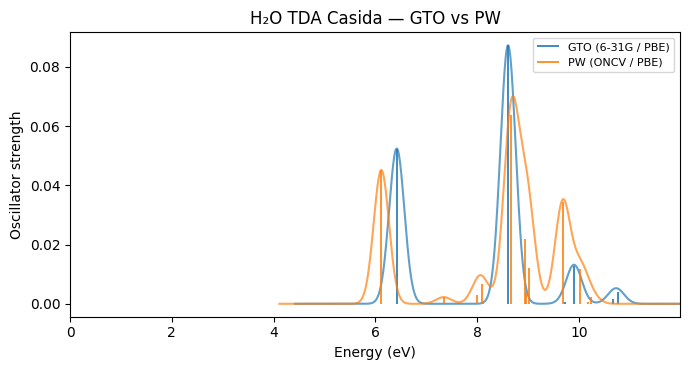

Δω₀ (PW − GTO) = -0.3026018665286818 eV


In [20]:
fig, ax = plt.subplots(figsize=(7, 3.8))
plot_sticks(gto_res, ax=ax, label="GTO (6-31G / PBE)", color="C0", broaden_sigma_ev=0.15)
plot_sticks(pw_res, ax=ax, label="PW (ONCV / PBE)", color="C1", broaden_sigma_ev=0.15)
ax.set_title("H₂O TDA Casida — GTO vs PW")
ax.set_xlim(0, max(omega_ev(gto_res).max(), omega_ev(pw_res).max()) + 1)
plt.tight_layout()
plt.show()

print("Δω₀ (PW − GTO) =", float(omega_ev(pw_res)[0] - omega_ev(gto_res)[0]), "eV")